# IG visualizations

Sample 3 true positives and 3 true negatives directly from `tests/test_IG_output.jsonl`, then render the top-abundance tokens for each sample.


In [5]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd() / "src"))

from token_source_attributor.visualization import display_random_tp_tn_token_charts, display_random_monotonic_abundance_token_charts


In [6]:
# data inspection
'''
"# data inspection\n",
are there positive and negative gradients or only positive? (is there sign to this signal?
what is the mean, median, variance and mode of the IG gradients
Answers:
If abundance is 0, the gradient IS 0.

The species gradients are always 0. Since the model is Fixed Slot Attention, sequence length is an identical 1662 species vector in every sample, leading to the same exact deterministic species embedding for each sample.

The degree of abundance becomes the only sample signal provided by the data to the classifier. The species embeddings are provided by MLM pretraining.

*show them in k-mean with the species embedddings to prove they are learned


if there is sign does it mean that > 0 are drivers toward disease and < 0 are drivers toward health based on the log-odds target logit?
Yes.

[CLS] attention can tell you that this species abundance token is important but it cannot tell you why.

Integrated gradients can tell you its important and can tell you whether it leads to the diagnoses or away from it (signed gradients).
It can tease causation out of the model ether.

7382 samples

stats for all IG atributions
len:  12267222
mean -0.0011763345995437695
median 0.0
variance:  0.0663922222798484
range:  [-32.77887725830078, 36.831268310546875])

stats for IG atrributions with abundance 0
len:  11770398
mean 0.0
median 0.0
variance:  0.0
range:  [0.0, 0.0])

stats for IG atrributions with TP
len:  5665758
mean 0.002776577763198292
median 0.0
variance:  0.06383470980751133
range:  [-32.77887725830078, 23.896650314331055])


stats for IG atrributions with TN
len:  6601464
mean -0.004568952485895151
median 0.0
variance:  0.06856230674236866
range:  [-30.25447654724121, 36.831268310546875])




what is the mean median, variance and mode of all abundance scores?

stats for all abundance_scores
len:  12267222
mean 1.1133660905460094
median 0.0
mode 0
variance:  37.76271956695957
range:  [0, 50])

Abundance scores on TP samples:
stats for abundance_scores
len:  5665758
mean 0.9204831904221819
median 0.0
mode 0
variance:  31.42428089028839
range:  [0, 50])

Abundance scores on TN samples:
stats for abundance_scores
len:  6601464
mean 1.2789093449574216
median 0.0
mode 0
variance:  43.14339899830871
range:  [0, 50])

  
what is the mean median, mode and variance of the attention scores... should be bounded [0,1]
is attention being paid to tokens of 0 abundance? Yes, about an order of magnitude less than non zero abundance tokens.

stats for all attention_scores (Samples * vocab)
len:  12267222
mean 0.0006014432357802775
median 0.00030778421205468476
variance:  5.844569225386607e-06
range:  [7.09273517713882e-05, 0.222137451171875])

stats for attention scores on samples with 0 abundance 
len:  11770398
mean 0.00031654220391060515
median 0.00030326533305924386
variance:  1.245180729259016e-07
range:  [7.09273517713882e-05, 0.022158058360219002])

stats for attention scores on TP samples
len:  5665758
mean 0.000601446242652556
median 0.00034440589661244303
variance:  5.397691897813847e-06
range:  [8.064694702625275e-05, 0.20840618014335632])

stats for attention scores on TN samples
len:  6601464
mean 0.0006014406551086769
median 0.000268495234195143
variance:  6.22810517947479e-06
range:  [7.09273517713882e-05, 0.222137451171875])

'''
import json
from pathlib import Path

def load_samples(jsonl_path: str | Path) -> list[dict]:
    samples = []
    with Path(jsonl_path).open(encoding="utf-8") as jsonl_file:
        for line in jsonl_file:
            line = line.strip()
            if not line:
                continue

            record = json.loads(line)
            if record.get("record_type") == "batch":
                samples.extend(record.get("samples", []))
            else:
                samples.append(record)

    return samples

samples = load_samples("tests/test_IG_output.jsonl")
len(samples), samples[0].keys()


(7382, dict_keys(['record_type', 'dataset_path', 'checkpoint_path']))

In [87]:
'''
{'sample_number': 0,
 'sample_id': 'MV_FEI2_t1Q14',
 'study_id': '2021-03-31.AsnicarF_2017.relative_abundance',
 'disease': 'healthy',
 'label': 0,
 'pred': 0,
 'prediction_type': 'true_negative',
 'prob_healthy': 0.9992167949676514,
 'prob_ibd': 0.0007832193514332175,
 'confidence': 0.9992167949676514,
 'entropy': 0.006384559441357851,
 'tokens': [{'token_index': 0,
   'species_id': 0,
   'abundance_bin': 0,
   'ig_species': 0.0,
   'ig_abundance': 0.0,
   'ig_species_plus_abundance': 0.0,
   'cls_score': 0.0003602262295316905},
  {'token_index': 1,
   'species_id': 1,
   'abundance_bin': 0,
   'ig_species': 0.0,
   'ig_abundance': 0.0,
   'ig_species_plus_abundance': 0.0,
   'cls_score': 0.0004316550912335515},
'''
import numpy as np
meta, study_samples = samples[0],samples[1:]

sample_abundances = []
sample_attentions = []
sample_ig = []

attention_on_zero_abundances = []
for sample in study_samples:
    attention_scores = []
    sample_ig_scores = []
    if sample['prediction_type'] == 'true_negative':
        for token in sample['tokens']:
            assert token['ig_abundance'] == token['ig_species_plus_abundance']
            # if token['abundance_bin'] == 0:
            sample_ig.append(token['ig_abundance'])
            sample_attentions.append(token["cls_score"])
            sample_abundances.append(token['abundance_bin'])
            
    
    # sample_ig.append(sample_ig_scores)
    # sample_attentions.append(attention_scores)
        
abundance_scores = np.array(sample_abundances)
sample_attentions_np = np.array(sample_attentions)
sample_ig_np = np.array(sample_ig)
print('abundance scores', abundance_scores.shape[0])
print('sample attentions', sample_attentions_np.shape[0], 'len sample scores, sample_attentions_np.shape[1]')
print('sample igs ', sample_ig_np.shape[0], 'len sample scores , sample_ig_np.shape[1]')


            


abundance scores 6601464
sample attentions 6601464 len sample scores, sample_attentions_np.shape[1]
sample igs  6601464 len sample scores , sample_ig_np.shape[1]


In [88]:
def get_stats(np_array, name):
    print(f'stats for {name}')
    print('len: ', np.size(np_array))
    print(f'mean', np_array.mean())
    print(f'median', np.median(np_array))
    try:
        print(f'mode', np.bincount(np_array).argmax())
    except Exception:
        print('could not compute bincount')
    print(f'variance: ', np.var(np_array))
    print('range: ', f'[{np.min(np_array)}, {np.max(np_array)}])')
    
get_stats(abundance_scores, 'abundance_scores')
get_stats(sample_attentions_np, 'attention_scores')
get_stats(sample_ig_np, 'sample ig scores')

stats for abundance_scores
len:  6601464
mean 1.2789093449574216
median 0.0
mode 0
variance:  43.14339899830871
range:  [0, 50])
stats for attention_scores
len:  6601464
mean 0.0006014406551086769
median 0.000268495234195143
could not compute bincount
variance:  6.22810517947479e-06
range:  [7.09273517713882e-05, 0.222137451171875])
stats for sample ig scores
len:  6601464
mean -0.004568952485895151
median 0.0
could not compute bincount
variance:  0.06856230674236866
range:  [-30.25447654724121, 36.831268310546875])


stats for attention_scores
len:  7381
mean 0.0006014432357802775
median 0.00030778421205468476
variance:  5.844569225386607e-06
range:  [7.09273517713882e-05, 0.222137451171875])


In [ ]:
display_random_tp_tn_token_charts(
    jsonl_path="tests/test_IG_output.jsonl",
    species_vocab_path="src/token_source_attributor/data/species_vocab.txt",
    samples_per_class=3,
    top_k=10,
    seed=7,
)

# maybe give more importance to visualizing items with lower abundance but higher IG?
# are there IG given to 0 abundance?

# you can add up the scores below if the sum > 0, model predicts IBD, if < 0 model predicts healthy
#YES!
# model accuracy is 93% for IBD
# 



{'true_positive': [{'batch_index': 196,
   'sample_number': 6300,
   'sample_id': 'HSMA33LH',
   'study_id': '2021-10-14.HMP_2019_ibdmdb.relative_abundance',
   'disease': 'IBD',
   'label': 1,
   'pred': 1,
   'prediction_type': 'true_positive',
   'prob_healthy': 0.0008286806405521929,
   'prob_ibd': 0.9991713762283325,
   'confidence': 0.9991713762283325,
   'entropy': 0.006708329543471336,
   'tokens': [{'token_index': 0,
     'species_id': 0,
     'abundance_bin': 0,
     'ig_species': 0.0,
     'ig_abundance': 0.0,
     'ig_species_plus_abundance': 0.0,
     'cls_score': 0.0003335267538204789},
    {'token_index': 1,
     'species_id': 1,
     'abundance_bin': 0,
     'ig_species': 0.0,
     'ig_abundance': 0.0,
     'ig_species_plus_abundance': 0.0,
     'cls_score': 0.0004177129303570837},
    {'token_index': 2,
     'species_id': 2,
     'abundance_bin': 0,
     'ig_species': 0.0,
     'ig_abundance': 0.0,
     'ig_species_plus_abundance': 0.0,
     'cls_score': 0.000373689166

In [6]:
display_random_monotonic_abundance_token_charts(
    jsonl_path="tests/test_IG_output.jsonl",
    species_vocab_path="src/token_source_attributor/data/species_vocab.txt",
    samples_per_class=3,
    seed=7,
)

{'true_positive': [{'batch_index': 34,
   'sample_number': 1118,
   'sample_id': 'CSM79HM9_P',
   'study_id': '2021-03-31.HMP_2019_ibdmdb.relative_abundance',
   'disease': 'IBD',
   'label': 1,
   'pred': 1,
   'prediction_type': 'true_positive',
   'prob_healthy': 0.000830029952339828,
   'prob_ibd': 0.9991699457168579,
   'confidence': 0.9991699457168579,
   'entropy': 0.006717982701957226,
   'tokens': [{'token_index': 0,
     'species_id': 0,
     'abundance_bin': 0,
     'ig_species': 0.0,
     'ig_abundance': 0.0,
     'ig_species_plus_abundance': 0.0,
     'cls_score': 0.0003359088150318712},
    {'token_index': 1,
     'species_id': 1,
     'abundance_bin': 0,
     'ig_species': 0.0,
     'ig_abundance': 0.0,
     'ig_species_plus_abundance': 0.0,
     'cls_score': 0.0003606387763284147},
    {'token_index': 2,
     'species_id': 2,
     'abundance_bin': 0,
     'ig_species': 0.0,
     'ig_abundance': 0.0,
     'ig_species_plus_abundance': 0.0,
     'cls_score': 0.000359149707

In [114]:
'''
{'sample_number': 0,
 'sample_id': 'MV_FEI2_t1Q14',
 'study_id': '2021-03-31.AsnicarF_2017.relative_abundance',
 'disease': 'healthy',
 'label': 0,
 'pred': 0,
 'prediction_type': 'true_negative',
 'prob_healthy': 0.9992167949676514,
 'prob_ibd': 0.0007832193514332175,
 'confidence': 0.9992167949676514,
 'entropy': 0.006384559441357851,
 'tokens': [{'token_index': 0,
   'species_id': 0,
   'abundance_bin': 0,
   'ig_species': 0.0,
   'ig_abundance': 0.0,
   'ig_species_plus_abundance': 0.0,
   'cls_score': 0.0003602262295316905},
  {'token_index': 1,
   'species_id': 1,
   'abundance_bin': 0,
   'ig_species': 0.0,
   'ig_abundance': 0.0,
   'ig_species_plus_abundance': 0.0,
   'cls_score': 0.0004316550912335515},
'''
import numpy as np
from collections import defaultdict

def _load_species_vocab(species_vocab_path: str | Path) -> list[str]:
    with Path(species_vocab_path).open(encoding="utf-8") as vocab_file:
        return [line.strip() for line in vocab_file if line.strip()]
    
meta, study_samples = samples[0],samples[1:]

top_20 = {}
bottom_20 = {}
top_k_per_sample = 20
vocab = _load_species_vocab("src/token_source_attributor/data/species_vocab.txt")
sample_cls_attention_matrix = []
to_species = lambda clade: clade.split('|')[-1]
species_prevalence = defaultdict(int)

ig_positive_matrix = [] # for each sample and species, their positive signals
ig_negative_matrix = [] # for each sample and species, their negative signals
ig_pos_plus_neg_matrix = [] # for each sample and species, the difference of their signals (more positive or more negative over all samples)

ig_net_unit_signal = []

# abundances to correspond with the pos, or neg average signals 
ab_pos_matrix = []
ab_neg_matrix = []
ab_net_matrix = []
for sample in study_samples:
    sample_attention = []
    ig_pos_sample = []
    ig_neg_sample = []
    ig_pos_neg_sample = []
    ab_pos_sample = []
    ab_neg_sample = []
    ab_net_sample = []
    ig_net_unit_sig_sample = []
    
    for token in sample["tokens"]:
        if token["abundance_bin"] != 0:
            # it exists
            species_prevalence[token["species_id"]] += 1
            sample_attention.append(token["cls_score"])
        else:
            sample_attention.append(np.nan)
        
        # dont need to check abundance here bc if gradient is 0, abundance is 0
        # already checked that
        # fill both pos and neg matrices with values for every token (col) and every sample (row)
        if token["ig_species_plus_abundance"] > 0:
            assert token["abundance_bin"] != 0 # nothing wrong with checking our assumptions
            ig_pos_sample.append(token["ig_species_plus_abundance"])
            ig_neg_sample.append(np.nan)
            ig_pos_neg_sample.append(token["ig_species_plus_abundance"])
            ab_pos_sample.append(token["abundance_bin"])
            ab_neg_sample.append(np.nan)
            ab_net_sample.append(token["abundance_bin"])
            
            ig_net_unit_sig_sample.append(token["ig_species_plus_abundance"] / token["abundance_bin"])
        elif token["ig_species_plus_abundance"] < 0:
            assert token["abundance_bin"] != 0
            ig_neg_sample.append(token["ig_species_plus_abundance"])
            ig_pos_sample.append(np.nan)
            ig_pos_neg_sample.append(token["ig_species_plus_abundance"])
            ab_neg_sample.append(token["abundance_bin"])
            ab_pos_sample.append(np.nan)
            ab_net_sample.append(token["abundance_bin"])
            
            ig_net_unit_sig_sample.append(token["ig_species_plus_abundance"] / token["abundance_bin"])
        else:
            assert token["ig_species_plus_abundance"] == 0
            assert token["abundance_bin"] == 0
            
            ig_pos_sample.append(np.nan)
            ig_neg_sample.append(np.nan)
            ig_pos_neg_sample.append(np.nan)
            
            ab_pos_sample.append(np.nan)
            ab_neg_sample.append(np.nan)
            ab_net_sample.append(np.nan)
            
            ig_net_unit_sig_sample.append(np.nan)
    
    assert len(ig_pos_sample) == len(ig_neg_sample)
    ig_positive_matrix.append(ig_pos_sample)
    ig_negative_matrix.append(ig_neg_sample)
    sample_cls_attention_matrix.append(sample_attention)
    ig_pos_plus_neg_matrix.append(ig_pos_neg_sample)
    ab_pos_matrix.append(ab_pos_sample)
    ab_neg_matrix.append(ab_neg_sample)
    ab_net_matrix.append(ab_net_sample)
    ig_net_unit_signal.append(ig_net_unit_sig_sample)
    
sample_cls_attention_matrix_np = np.array(sample_cls_attention_matrix)
ig_pos_matrix_np = np.array(ig_positive_matrix)
ig_neg_matrix_np = np.array(ig_negative_matrix)
ig_pos_plus_neg_matrix_np = np.array(ig_pos_plus_neg_matrix)

ig_net_unit_signal_np = np.array(ig_net_unit_signal)

ab_pos_matrix_np = np.array(ab_pos_matrix)
ab_neg_matrix_np = np.array(ab_neg_matrix)
ab_net_matrix_np = np.array(ab_net_matrix)
        
            
prevalence_raw_counts = sorted(species_prevalence.items(), key=lambda x: x[1], reverse=True)
prevalence_normalized = [(id, count/len(study_samples)) for (id,count) in prevalence_raw_counts]

prevalence_filtered = [(id,freq) for (id,freq) in prevalence_normalized if freq >= 0.05]
prevalence_filtered

# take this to numpy 
# build an attention matrix (samples, species)
# filter species by prevalence_filtered
# mask 0 value
# collapse sum across rows
# top 10
    
    # # top 20 and bottom 20
    # top_20 = []
    # bottom_20 = []
    
    # # sample_count += 1
    # top_tokens = sorted(
    #     sample["tokens"],
    #     key=lambda token: (
    #         -float(token["ig_species_plus_abundance"]),
    #         int(token["token_index"]),
    #     ),
    # )[:top_k_per_sample]
    # bottom_tokens = sorted(
    #     sample["tokens"],
    #     key=lambda token: (
    #         float(token["ig_species_plus_abundance"]),
    #         int(token["token_index"]),
    #     ),
    # )[:top_k_per_sample]
    
    # # print(top_tokens)
    # # print(bottom_tokens)
    # for sample in top_tokens:
    #     top_20[sample['sample_id']].get()
        
    
    # break
            
    


[(1022, 0.8588267172469854),
 (310, 0.8070722124373391),
 (309, 0.8051754504809646),
 (909, 0.7570789865871833),
 (965, 0.7455629318520526),
 (1023, 0.7366210540577157),
 (921, 0.7364855710608319),
 (939, 0.7321501151605474),
 (427, 0.7229372713724428),
 (286, 0.7122341146186154),
 (932, 0.6969245359707357),
 (249, 0.6841891342636499),
 (75, 0.6787698143882943),
 (1054, 0.6703698685814931),
 (978, 0.6699634195908414),
 (916, 0.6591247798401301),
 (975, 0.6472022761143477),
 (1015, 0.645440997154857),
 (889, 0.6423248882265276),
 (308, 0.6383958813168947),
 (931, 0.6351442893916813),
 (888, 0.6324346294540035),
 (976, 0.6121121799214199),
 (929, 0.6007316081831731),
 (795, 0.5919252133857201),
 (977, 0.5894865194418101),
 (1413, 0.583254301585151),
 (923, 0.5794607776724021),
 (417, 0.5698414848936458),
 (413, 0.5694350359029942),
 (265, 0.5626608860587996),
 (332, 0.5562931852052567),
 (431, 0.5477577564015716),
 (311, 0.5293320688253624),
 (922, 0.5152418371494377),
 (1028, 0.50684189

In [11]:
def rank_species(mat, mat_ab, species_id_filter, k=15, desc=False):
    mat_filtered = mat[:, species_id_filter]
    mat_ab_filtered = mat_ab[:, species_id_filter]
    mat_mean = np.nanmean(mat_filtered, axis=0)
    mat_ab_mean = np.nanmean(mat_ab_filtered, axis=0)
    
    # sort on signal
    if desc:
        top_k_mat_idx = np.argsort(mat_mean)[-k:][::-1]
    else:  
        top_k_mat_idx = np.argsort(mat_mean)[:k]
        
    top_k_mat_scores = mat_mean[top_k_mat_idx]
    top_k_mat_ab = mat_ab_mean[top_k_mat_idx]
    top_k_mat_species_ids = species_id_filter[top_k_mat_idx]
    top_15_mat_species = [(to_species(vocab[specie]), avg_score, avg_ab, specie) for specie,avg_score,avg_ab in zip(list(top_k_mat_species_ids), list(top_k_mat_scores), list(top_k_mat_ab))]
    return top_15_mat_species

In [116]:
species_id_filter = np.array(prevalence_filtered, dtype=int)[:,0]

mask = (np.isnan(sample_cls_attention_matrix_np))

assert mask.sum() == 11770398 # 0 abundance global total in data

#==========================POS IG=========================
# signal
pos_species = rank_species(ig_pos_matrix_np, ab_pos_matrix_np, species_id_filter, k=15, desc=True)
print('top 15 pos species: ', pos_species) # IBD drivers
#==================== NET IG ===========================
top_net_species = rank_species(ig_pos_plus_neg_matrix_np, ab_net_matrix_np, species_id_filter, k=15, desc=True)
print('top 15 net species: ', top_net_species) # ibd net drivers across all signals and abundances (except 0 abundance and 0 signal)
    
#==========================NEG IG========================
neg_species = rank_species(ig_neg_matrix_np, ab_neg_matrix_np, species_id_filter, k=15, desc=False)
print('top 15 neg species: ', neg_species) # health drivers

#==================== NET IG ===========================
bottom_net_species = rank_species(ig_pos_plus_neg_matrix_np, ab_net_matrix_np, species_id_filter, k=15, desc=False)
print('bottom 15 net species: ', bottom_net_species) # health net drivers across all signals and abundances (except 0 abundance and 0 signal)

#================== MOST VIRULENT SPECIES (per unit abundance) ======================
top_net_unit_signal_species = rank_species(ig_net_unit_signal_np, np.zeros_like(ig_net_unit_signal_np), species_id_filter, k=15, desc=True)
print('top 15 net unit signal species: ', top_net_unit_signal_species) # ibd net drivers across all signals and abundances (except 0 abundance and 0 signal)

#================== MOST HEALTHY SPECIES (per unit abundance) ========================
bottom_net_unit_signal_species = rank_species(ig_net_unit_signal_np, np.zeros_like(ig_net_unit_signal_np), species_id_filter, k=15, desc=False)
print('bottom 15 net unit signal species: ', bottom_net_unit_signal_species) # ibd net drivers across all signals and abundances (except 0 abundance and 0 signal)


#==========================Attention======================
# filter the > 5% prevalent species, keep all rows, filter across columns
samples_cls_matrix_filtered_species = sample_cls_attention_matrix_np[:,species_id_filter]
print('new prevalence attn matrix ', samples_cls_matrix_filtered_species.shape[0], samples_cls_matrix_filtered_species.shape[1])

# mean across rows (species or column attn mean)
filtered_species_attn_means = np.nanmean(samples_cls_matrix_filtered_species, axis=0)
top_10_idx = np.argsort(filtered_species_attn_means)[-15:][::-1]
top_10_scores = filtered_species_attn_means[top_10_idx]

# species_id_filter entries are the mapping back to the unfiltered species working set
# working_set -> filter_set entries -> filter_set
# working_set <- filter_set entries <- argmax
top_10_species_ids = species_id_filter[top_10_idx]
top_10_species = [(to_species(vocab[specie]), score) for specie,score in zip(list(top_10_species_ids), list(top_10_scores))]
top_10_species





top 15 pos species:  [('s__Bacteroides_sp_CAG_144', np.float64(2.94470695746122), np.float64(32.56464379947229), np.int64(295)), ('s__Faecalitalea_cylindroides', np.float64(2.13244050177712), np.float64(32.76978417266187), np.int64(1069)), ('s__Eisenbergiella_massiliensis', np.float64(1.9686192394466784), np.float64(23.008610086100862), np.int64(935)), ('s__Clostridium_sp_CAG_242', np.float64(1.8645495120187456), np.float64(23.610208816705338), np.int64(844)), ('s__Firmicutes_bacterium_CAG_94', np.float64(1.708064128366816), np.float64(22.650033266799735), np.int64(1086)), ('s__Bacteroides_coprocola', np.float64(1.467765077024639), np.float64(34.76984126984127), np.int64(269)), ('s__Blautia_hydrogenotrophica', np.float64(1.4508988333268322), np.float64(17.75), np.int64(915)), ('s__Bacteroides_fragilis', np.float64(1.4507003879891749), np.float64(36.995661605206074), np.int64(278)), ('s__Roseburia_sp_CAG_303', np.float64(1.424316553824013), np.float64(29.350746268656717), np.int64(982))

[('s__Staphylococcus_epidermidis', np.float64(0.04283806466371035)),
 ('s__Collinsella_massiliensis', np.float64(0.034176942398901)),
 ('s__Parabacteroides_merdae', np.float64(0.031123471724704133)),
 ('s__Dialister_invisus', np.float64(0.026616489668828503)),
 ('s__Roseburia_sp_CAG_303', np.float64(0.026396111896272955)),
 ('s__Bacteroides_clarus', np.float64(0.025677245658683918)),
 ('s__Bacteroides_faecis', np.float64(0.02540813677613114)),
 ('s__Bacteroides_coprocola', np.float64(0.024501186291012785)),
 ('s__Enterococcus_faecalis', np.float64(0.024456717132304427)),
 ('s__Prevotella_sp_885', np.float64(0.023956593348992618)),
 ('s__Paraprevotella_xylaniphila', np.float64(0.02243357194340681)),
 ('s__Prevotella_sp_CAG_520', np.float64(0.022141132987951184)),
 ('s__Eubacterium_eligens', np.float64(0.021626812116466998)),
 ('s__Clostridium_clostridioforme', np.float64(0.019913540188014053)),
 ('s__Bacteroides_nordii', np.float64(0.019669499615521186))]

In [ ]:
a = np.array([1,2,3])





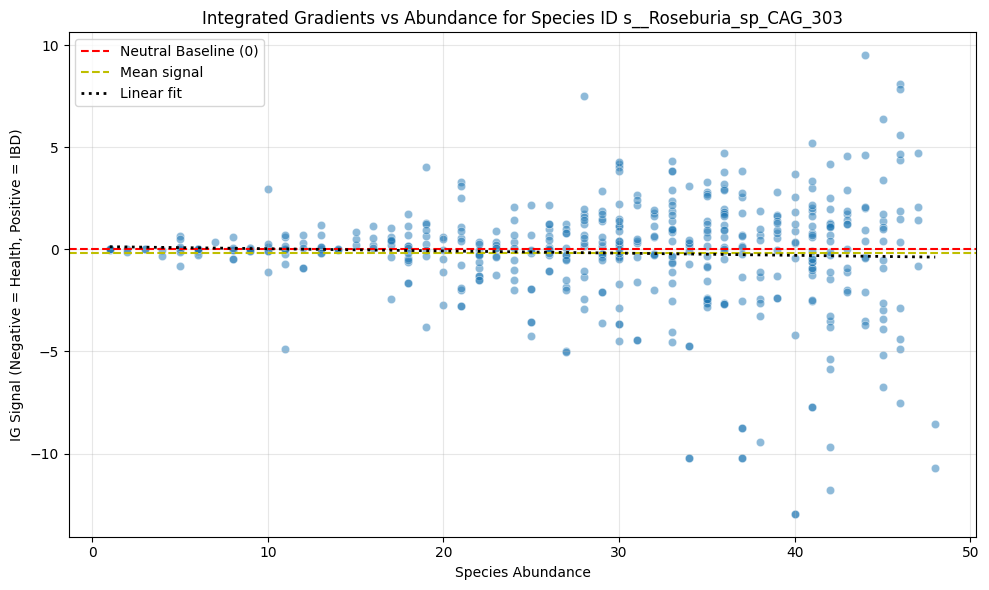

In [106]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming your matrices are named `signal_matrix` and `abundance_matrix`
# Both should be shape (num_samples, num_species)
species_idx = 982

# 1. Extract the specific column for species 1069
signals = ig_pos_plus_neg_matrix_np[:, species_idx]
abundances = ab_net_matrix_np[:, species_idx]

# 2. Create a mask to filter out np.nan values
# This ensures we only plot samples where the species actually exists
valid_mask = ~np.isnan(signals) & ~np.isnan(abundances)

valid_signals = signals[valid_mask]
valid_abundances = abundances[valid_mask]

mean_valid_signal = valid_signals.mean(axis=0)


# 3. Plot the data
plt.figure(figsize=(10, 6))

# X-axis: Abundance, Y-axis: Signal (IG Score)
plt.scatter(valid_abundances, valid_signals, alpha=0.5, edgecolors='w', linewidth=0.5)

# Add a horizontal line at y=0 to clearly see the health vs. disease threshold
plt.axhline(y=0, color='r', linestyle='--', label='Neutral Baseline (0)')

# Add a mean line to show where the signal is over all abundance 
plt.axhline(y=mean_valid_signal, color='y', linestyle='--', label='Mean signal')

# Add a linear regressor line, given abundance predict signal
m, b = np.polyfit(valid_abundances, valid_signals, 1)
x_line = np.linspace(valid_abundances.min(), valid_abundances.max(), 100)
y_line = m * x_line + b
plt.plot(x_line, y_line, color='k', linestyle=':', linewidth=2, label='Linear fit')

# Formatting
plt.title(f'Integrated Gradients vs Abundance for Species ID {to_species(vocab[species_idx])}')
plt.xlabel('Species Abundance')
plt.ylabel('IG Signal (Negative = Health, Positive = IBD)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

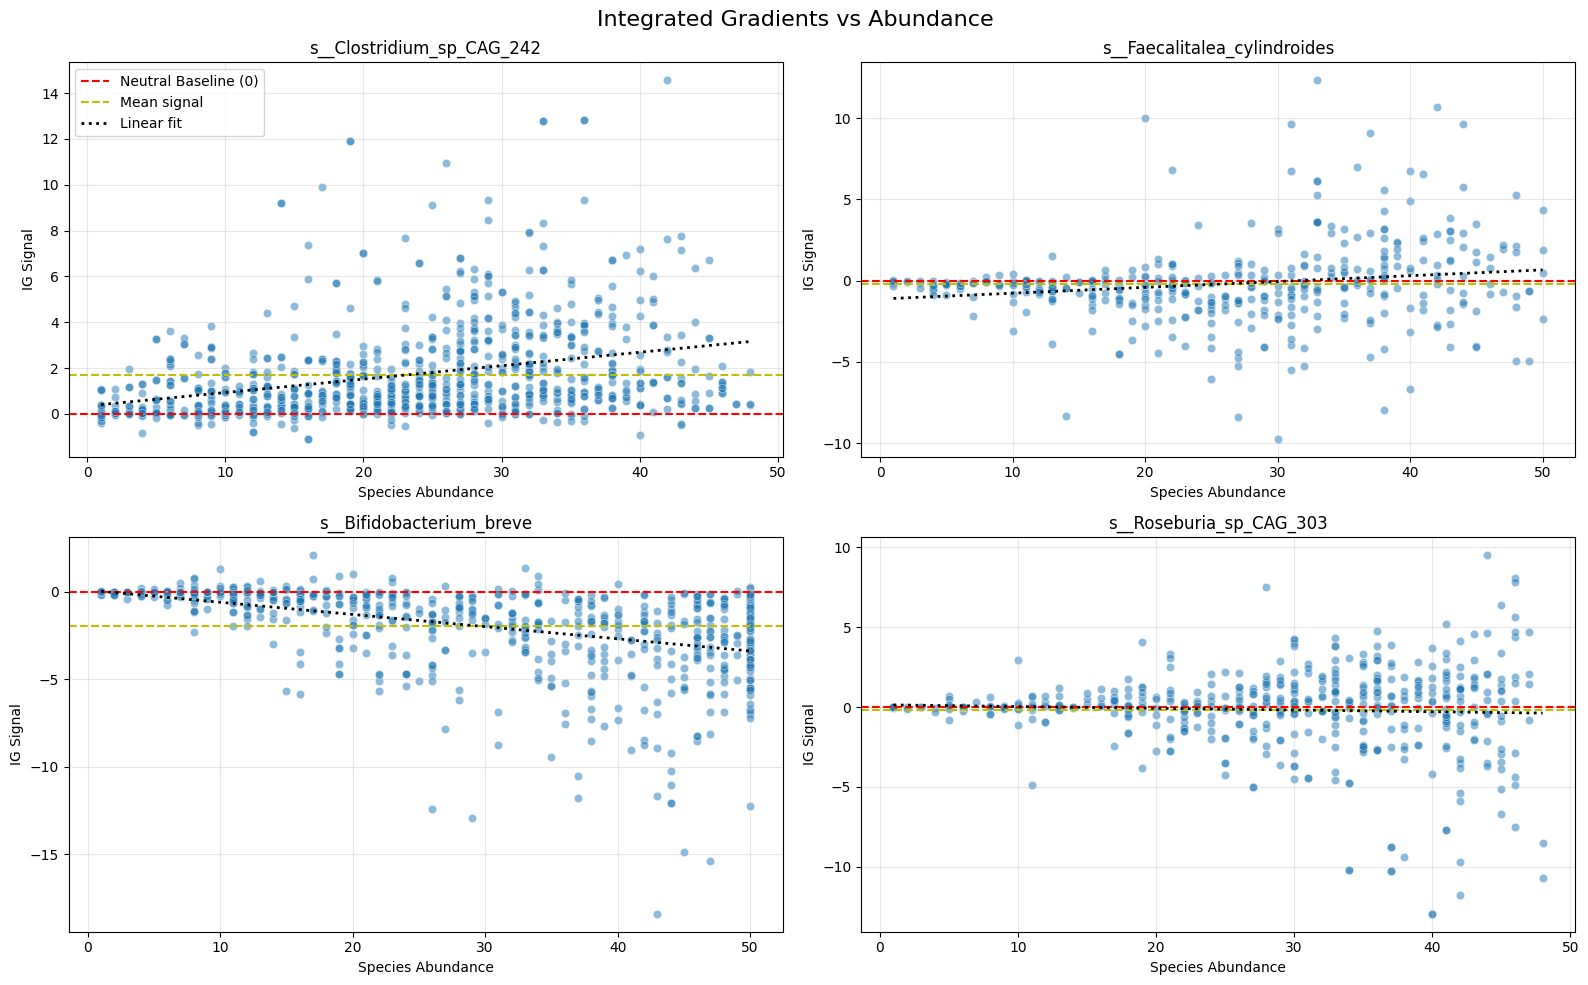

In [112]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the 4 species IDs you want to plot
species_ids = [844, 1069, 67, 982]  # Replace with the IDs you want to investigate

# 2. Create a 2x2 grid of subplots (16x10 inches is usually good for a 2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Flatten the 2x2 axes array into a 1D list so we can easily loop over it
axes = axes.flatten()

for i, sp_idx in enumerate(species_ids):
    ax = axes[i]  # Get the current tile
    
    # Extract data for this specific species
    signals = ig_pos_plus_neg_matrix_np[:, sp_idx]
    abundances = ab_net_matrix_np[:, sp_idx]

    # Create mask to filter out np.nan values
    valid_mask = ~np.isnan(signals) & ~np.isnan(abundances)
    valid_signals = signals[valid_mask]
    valid_abundances = abundances[valid_mask]

    # Check if data exists to avoid crashing
    if len(valid_signals) == 0:
        ax.set_title(f'Species ID {sp_idx} (No valid data)')
        ax.axis('off')
        continue

    mean_valid_signal = valid_signals.mean()

    # Scatter plot on the specific tile (ax instead of plt)
    ax.scatter(valid_abundances, valid_signals, alpha=0.5, edgecolors='w', linewidth=0.5)

    # Add lines
    ax.axhline(y=0, color='r', linestyle='--', label='Neutral Baseline (0)')
    ax.axhline(y=mean_valid_signal, color='y', linestyle='--', label='Mean signal')

    # Linear regressor
    if len(valid_abundances) > 1: # Need at least 2 points for a line
        m, b = np.polyfit(valid_abundances, valid_signals, 1)
        x_line = np.linspace(valid_abundances.min(), valid_abundances.max(), 100)
        y_line = m * x_line + b
        ax.plot(x_line, y_line, color='k', linestyle=':', linewidth=2, label='Linear fit')

    # Formatting for this specific tile
    # Using try/except in case `to_species` or `vocab` isn't accessible in this scope
    try:
        title_name = to_species(vocab[sp_idx])
    except NameError:
        title_name = f"Species ID {sp_idx}"

    ax.set_title(title_name)
    ax.set_xlabel('Species Abundance')
    ax.set_ylabel('IG Signal')
    ax.grid(True, alpha=0.3)
    
    # Only show legend on the first tile to avoid clutter
    if i == 0:
        ax.legend()

# Overall figure formatting
plt.suptitle('Integrated Gradients vs Abundance', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

In [32]:
v = np.array([10,20,30,40,50])
t = np.array([1,1,1,1,1])

v @ t

np.int64(150)

In [53]:
# Measure every 0.001 seconds instead of every 1 second
infantesimal = 0.001
t = np.arange(0, 5 + infantesimal, infantesimal)
v = 10 * t

# infantesimal (differential), the smaller this is the more accurate the result
Δt = np.full(len(t), infantesimal)

# ∫ 10t dt, (dx is which axis are you slicing your very thin slices from)
v @ Δt

np.float64(125.02499999999999)

In [98]:

def integral_riemann_approx(l,r,n,fx,strategy='middle'):
    print(f'left bound = {l}\nright bound = {r}\nrectangles = {n}')
    step = (r-l)/n
    print('Δx step = ', step)
    x1 = np.arange(l, r, step)
    x2 = np.arange(l+step, r+step, step)

    # midpoint Riemann approximation, left endpoints underestimate, right overestimate, middle slightly overestimate
    x = (x1 + x2) / 2
    
    x_points = None
    if strategy == 'left':
        x_points = x1
        print('left rectangle points = ', x1)
    elif strategy == 'right':
        x_points = x2
        print('right rectangle points = ', x2)
    elif strategy == 'middle':
        x_points = x
        print('middle rectangle points = ', x)
        

    y = fx(x_points)
    dx = np.full(len(x_points), step)
    print('height = ', y)
    print(f'{strategy} Riemann approximation', y @ dx)

l = 2
r = 8
n = 3
fx = lambda x: -0.5*x**3 + 5*x**2 - 3*x - 8
integral_riemann_approx(l,r,n,fx,'left')
integral_riemann_approx(l,r,n,fx,'middle')
integral_riemann_approx(l,r,n,fx,'right')


left bound = 2
right bound = 8
rectangles = 3
Δx step =  2.0
left rectangle points =  [2. 4. 6.]
height =  [ 2. 28. 46.]
left Riemann approximation 152.0
left bound = 2
right bound = 8
rectangles = 3
Δx step =  2.0
middle rectangle points =  [3. 5. 7.]
height =  [14.5 39.5 44.5]
middle Riemann approximation 197.0
left bound = 2
right bound = 8
rectangles = 3
Δx step =  2.0
right rectangle points =  [4. 6. 8.]
height =  [28. 46. 32.]
right Riemann approximation 212.0


In [ ]:
#f(x) = ∂𝛼x/∂x_i
fx_local_grad = lambda x: (0 + x*(50 - 0)) / 1
integral_riemann_approx(0,1,10, fx_local_grad, strategy='middle')

# integrated gradients get the local grad at each interval along the curve of local grads

left bound = 0
right bound = 1
rectangles = 10
Δx step =  0.1
middle rectangle points =  [0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
height =  [ 2.5  7.5 12.5 17.5 22.5 27.5 32.5 37.5 42.5 47.5]
middle Riemann approximation 25.000000000000004


last questions to answer

1. The widening variance as abundance increases is the result of the avg species signal per unit of abundance

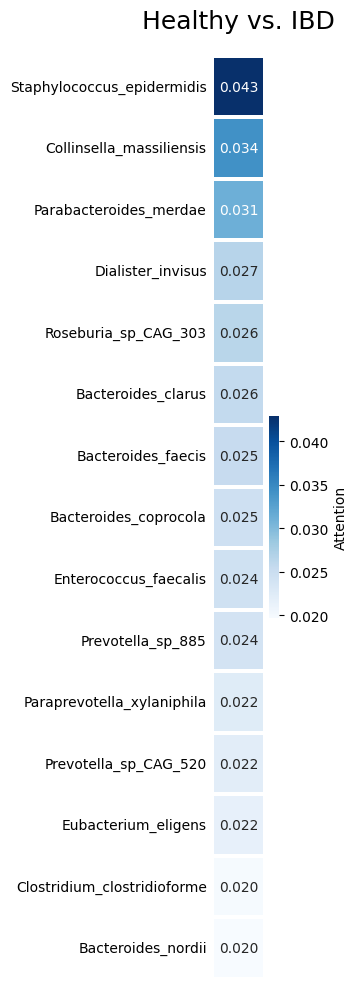

In [60]:
'''
Attention chart recreation according to their paper
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Your provided data
data = top_10_species
# Clean up the species names (remove 's__') and extract values
species = [item[0].replace('s__', '') for item in data]
values = np.array([item[1] for item in data])

# Create a DataFrame for seaborn (heatmaps require 2D arrays)
df = pd.DataFrame(values, index=species, columns=['Attention'])

# Set up the matplotlib figure (tall and narrow)
fig, ax = plt.subplots(figsize=(3.5, 10))

# Draw the heatmap
sns.heatmap(
    df,
    annot=True,            # Write the data value in each cell
    fmt=".3f",             # Format to 3 decimal places to match the reference image
    cmap="Blues",          # The clear-to-blue color gradient
    linewidths=1.5,        # Add white grid lines between cells
    linecolor='white',
    cbar_kws={
        'label': 'Attention', 
        'shrink': 0.6    # Shrink the colorbar to match the image proportions
    }, 
    ax=ax
)

# Formatting to match the image's minimalist style
ax.set_title("Healthy vs. IBD", fontsize=18, pad=20)
ax.set_ylabel("")          # Remove the default 'species' y-label
ax.set_xticklabels([])     # Remove the 'Attention' x-label at the bottom of the column
ax.tick_params(axis='both', which='both', length=0) # Remove tick marks

# Ensure nothing gets cut off
plt.tight_layout()
plt.show()


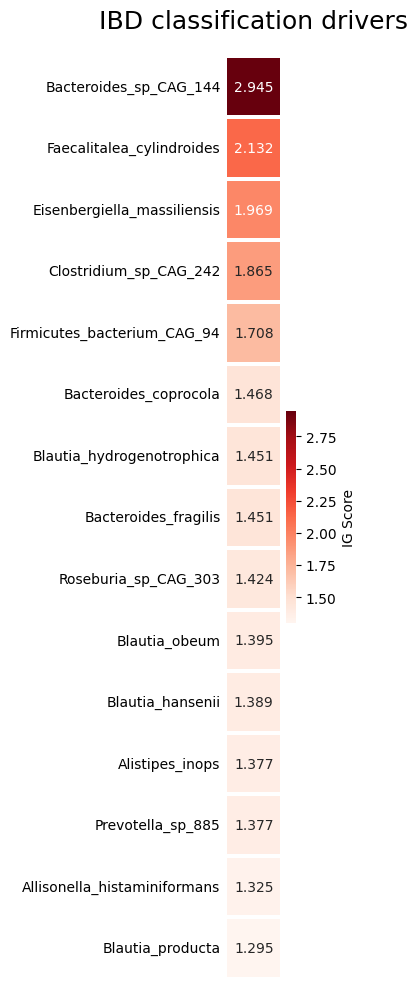

In [10]:
'''
Integrated Gradients: Pathogenic (IBD Drivers)
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your data is stored in a variable like this:
data = pos_species

# Clean up the species names (remove 's__') and extract values
species = [item[0].replace('s__', '') for item in data]
values = np.array([item[1] for item in data])

# Create a DataFrame for seaborn
df = pd.DataFrame(values, index=species, columns=['IG Score'])

# Set up the matplotlib figure (tall and narrow)
fig, ax = plt.subplots(figsize=(3.5, 10))

# Draw the heatmap
sns.heatmap(
    df,
    annot=True,            
    fmt=".3f",             
    cmap="Reds",           # Clear to Red gradient
    linewidths=1.5,        
    linecolor='white',
    cbar_kws={
        'label': 'IG Score', 
        'shrink': 0.6    
    }, 
    ax=ax
)

# Formatting
ax.set_title("IBD classification drivers", fontsize=18, pad=20)
ax.set_ylabel("")          
ax.set_xticklabels([])     
ax.tick_params(axis='both', which='both', length=0) 

# Ensure nothing gets cut off
plt.tight_layout()
plt.show()

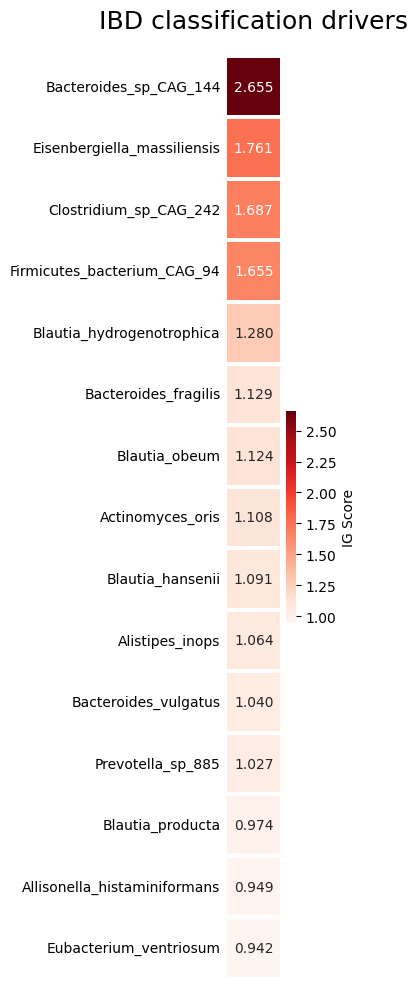

In [39]:
'''
Integrated Gradients: Pathogenic (IBD Drivers)
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your data is stored in a variable like this:
data = top_net_species

# Clean up the species names (remove 's__') and extract values
species = [item[0].replace('s__', '') for item in data]
values = np.array([item[1] for item in data])

# Create a DataFrame for seaborn
df = pd.DataFrame(values, index=species, columns=['IG Score'])

# Set up the matplotlib figure (tall and narrow)
fig, ax = plt.subplots(figsize=(3.5, 10))

# Draw the heatmap
sns.heatmap(
    df,
    annot=True,            
    fmt=".3f",             
    cmap="Reds",           # Clear to Red gradient
    linewidths=1.5,        
    linecolor='white',
    cbar_kws={
        'label': 'IG Score', 
        'shrink': 0.6    
    }, 
    ax=ax
)

# Formatting
ax.set_title("IBD classification drivers", fontsize=18, pad=20)
ax.set_ylabel("")          
ax.set_xticklabels([])     
ax.tick_params(axis='both', which='both', length=0) 

# Ensure nothing gets cut off
plt.tight_layout()
plt.show()

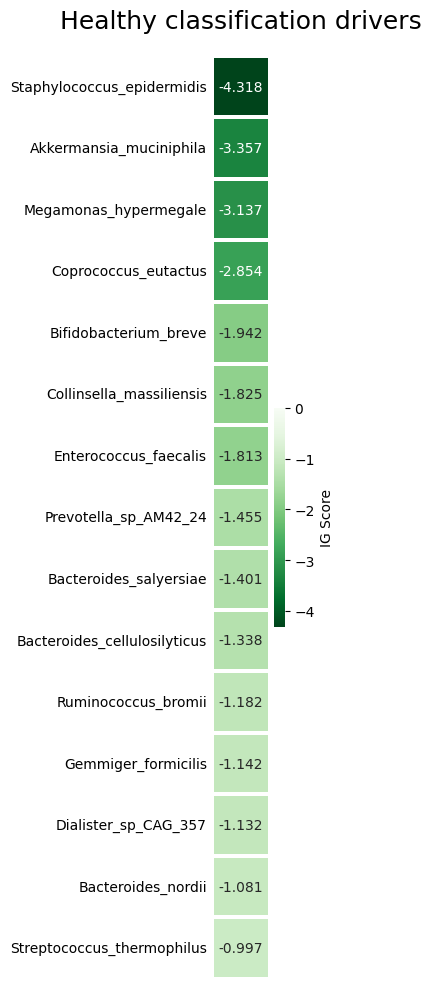

In [38]:
'''
Integrated Gradients: Protective (Health Drivers)
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your data is stored in a variable like this:
data = bottom_net_species

# Clean up the species names (remove 's__') and extract values
species = [item[0].replace('s__', '') for item in data]
values = np.array([item[1] for item in data])

# Create a DataFrame for seaborn
df = pd.DataFrame(values, index=species, columns=['IG Score'])

# Set up the matplotlib figure (tall and narrow)
fig, ax = plt.subplots(figsize=(3.5, 10))

# Draw the heatmap
sns.heatmap(
    df,
    annot=True,            
    fmt=".3f",             
    cmap="Greens_r",       # Reversed Greens (Dark green for highly negative)
    vmax=0,                # Force 0 to be the clear/white baseline
    linewidths=1.5,        
    linecolor='white',
    cbar_kws={
        'label': 'IG Score', 
        'shrink': 0.6    
    }, 
    ax=ax
)

# Formatting
ax.set_title("Healthy classification drivers", fontsize=18, pad=20)
ax.set_ylabel("")          
ax.set_xticklabels([])     
ax.tick_params(axis='both', which='both', length=0) 

# Ensure nothing gets cut off
plt.tight_layout()
plt.show()

In [ ]:
'''
k-means on token vector color coded by True positive and True negative
'''

In [99]:
vocab = _load_species_vocab("src/token_source_attributor/data/species_vocab.txt")
to_species = lambda clade: clade.split('|')[-1]

Backbone loaded successfully!
Clustering 1662 biological species in 512 dimensions...


/mnt/data/onelson/token-source-attribution/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/mnt/data/onelson/token-source-attribution/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


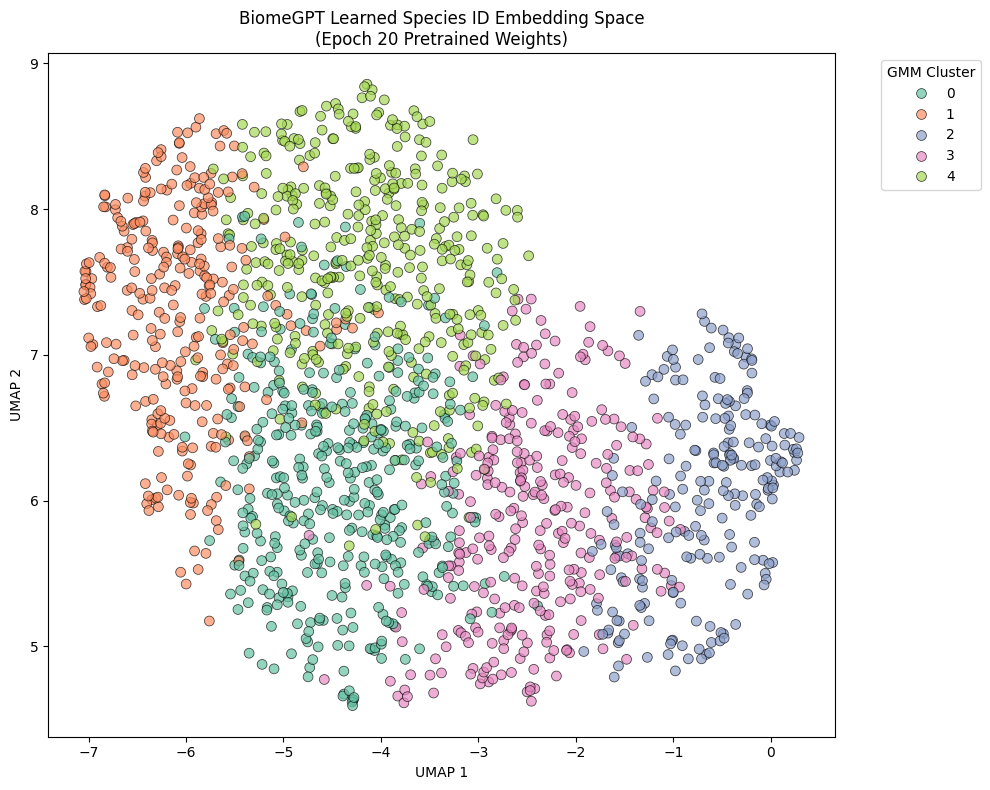

In [105]:
import torch
import numpy as np
import umap
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns
from token_source_attributor.models.biomgpt import BioMGPTEncoderBackbone
from token_source_attributor.data.dataset import BinnedMicrobiomeClassificationDataset

dataset = BinnedMicrobiomeClassificationDataset(
    path="src/token_source_attributor/data/classifier_stool_binned.tsv",
)

# Force CPU for UMAP and scikit-learn compatibility
device = torch.device("cpu")

# 1. Instantiate the naked backbone
backbone = BioMGPTEncoderBackbone(
    num_species=dataset.num_species,
    max_bin=50,
    d_model=512,
    n_layers=8,
    n_heads=8,
    dim_feedforward=512,
    dropout=0.1,
)

# Load directly to system RAM
pretrained_state_dict = torch.load(
    "checkpoints/biomgpt_pretrain_epoch_20.pt",
    map_location=device,
)

backbone_state_dict = {
    key.replace("backbone.", ""): value
    for key, value in pretrained_state_dict.items()
    if key.startswith("backbone.")
}

# 2. Load the weights and lock the model
backbone.load_state_dict(backbone_state_dict)
backbone.eval()
print("Backbone loaded successfully!")

# ---------------------------------------------------------
# The GMM / UMAP Clustering Pipeline
# ---------------------------------------------------------

# Extract the raw weights (no .cpu() needed since we loaded to CPU)
raw_weights = backbone.species_embedding.weight.detach().numpy()

# Dynamically find and drop the [CLS] token row
cls_index = backbone.cls_species_id
species_weights = np.delete(raw_weights, cls_index, axis=0)

print(f"Clustering {species_weights.shape[0]} biological species in {species_weights.shape[1]} dimensions...")

# Squash the 512D model weights down to a dense 15D manifold
reducer = umap.UMAP(n_components=15, random_state=42)
dense_embeddings = reducer.fit_transform(species_weights)

# Fit the GMM on the dense space
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
cluster_labels = gmm.fit_predict(dense_embeddings)

# Visual Reduction down to 2D for the plot
vis_reducer = umap.UMAP(n_components=2, random_state=42)
plot_embeddings = vis_reducer.fit_transform(species_weights)

# Plot the Model's Brain
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=plot_embeddings[:, 0], 
    y=plot_embeddings[:, 1], 
    hue=cluster_labels, 
    palette="Set2",
    s=50,
    edgecolor="k",
    alpha=0.7
)

plt.title("BiomeGPT Learned Species ID Embedding Space\n(Epoch 20 Pretrained Weights)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="GMM Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [121]:
# Assuming your vocab loading functions are defined:
# vocab = _load_species_vocab("src/token_source_attributor/data/species_vocab.txt")
# to_species = lambda clade: clade.split('|')[-1]

print("\n" + "="*50)
print("GMM CLUSTER ANALYSIS: TOP 10 CORE SPECIES BY ORDER")
print("="*50)

# 1. Get the probability matrix from the GMM
# Shape: (1662 species, 5 clusters)
cluster_probs = gmm.predict_proba(dense_embeddings)

NUM_CLUSTERS = 5 # Match your n_components

for cluster_id in range(NUM_CLUSTERS):
    # 2. Isolate the probability scores for this specific cluster
    probs_for_cluster = cluster_probs[:, cluster_id]
    
    # 3. Find the indices of the 10 species with the highest probability
    # argsort sorts ascending (lowest to highest), so we slice the last 10 and reverse [::-1]
    top_10_indices = np.argsort(probs_for_cluster)[-10:][::-1]
    
    print(f"\n--- Cluster {cluster_id} ---")
    to_order = lambda clade: clade.split('|')[-4]
    # 4. Map the indices back to human-readable species names
    for rank, idx in enumerate(top_10_indices):
        clade = to_order(vocab[idx])
        # species_name = to_species_and_more(clade)
        
        # Strip the 's__' prefix if it's there for a cleaner printout
        # clean_name = species_name.replace('s__', '')
        
        confidence = probs_for_cluster[idx]
        
        # Injecting the Species ID directly into the printout
        print(f"  {rank + 1}. [ID: {idx}] {clade} (Confidence: {confidence:.4f})")


GMM CLUSTER ANALYSIS: TOP 10 CORE SPECIES BY ORDER

--- Cluster 0 ---
  1. [ID: 1644] o__Eurotiales (Confidence: 1.0000)
  2. [ID: 915] o__Clostridiales (Confidence: 1.0000)
  3. [ID: 1560] o__Pseudomonadales (Confidence: 1.0000)
  4. [ID: 795] o__Lactobacillales (Confidence: 1.0000)
  5. [ID: 798] o__Lactobacillales (Confidence: 1.0000)
  6. [ID: 725] o__Lactobacillales (Confidence: 1.0000)
  7. [ID: 734] o__Lactobacillales (Confidence: 1.0000)
  8. [ID: 1529] o__Pseudomonadales (Confidence: 1.0000)
  9. [ID: 727] o__Lactobacillales (Confidence: 1.0000)
  10. [ID: 759] o__Lactobacillales (Confidence: 1.0000)

--- Cluster 1 ---
  1. [ID: 1628] o__Acholeplasmatales (Confidence: 1.0000)
  2. [ID: 979] o__Clostridiales (Confidence: 1.0000)
  3. [ID: 1008] o__Clostridiales (Confidence: 1.0000)
  4. [ID: 1074] o__Erysipelotrichales (Confidence: 1.0000)
  5. [ID: 1061] o__Erysipelotrichales (Confidence: 1.0000)
  6. [ID: 970] o__Clostridiales (Confidence: 1.0000)
  7. [ID: 147] o__Corynebac

In [116]:

to_order = lambda clade: clade.split('|')[-4:]
to_order(vocab[970])

['o__Clostridiales',
 'f__Lachnospiraceae',
 'g__Oribacterium',
 's__Oribacterium_asaccharolyticum']

In [ ]:
#writeup!

In [4]:
# search space 
1662 * 10**512

166200000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000